# Day 7 — Candidate Ranking Validation

## Objective

Validate the existing candidate scoring implementation using the actual
`data/scoring/candidate_scoring.py` implementation.

Day 7 validation covers:

1. One-feature-at-a-time scoring sensitivity
2. Candidate score-breakdown visualization, if actual ranked candidate output is available
3. Candidate reduction and ranking stability, if actual ranked output is available
4. Recall@1 / Recall@3 only if verified ground truth is available
5. Audit of evidence statements against actual numerical feature values
6. Documentation of unavailable / blocked items

## Data Integrity Rules

- No synthetic MMSIs or candidate records.
- No fabricated candidate scores.
- No fabricated ground truth.
- No Recall@1 / Recall@3 without verified ground truth.
- Formula validation must use the existing scoring implementation.
- Any unavailable downstream output is explicitly marked as blocked/leftover.

## Day 7 — Dependency Check

### Available

- Existing candidate scoring implementation:
  `data/scoring/candidate_scoring.py`
- Existing scoring tests:
  `tests/test_candidate_scoring.py`
- Scoring version: `v1.0`
- Six scoring features and their implemented weights are available.
- Existing implementation can be directly imported for sensitivity validation.

### Currently unavailable / blocked

- Persisted real candidate ranking output
- Candidate feature values from a compatible end-to-end ranking run
- Verified candidate ground truth
- Recall@1 / Recall@3 ground truth

Therefore, Day 7 will first validate the scoring implementation itself.
Downstream ranking/recall tasks will only be performed when their required
evidence becomes available.

## 1. Existing scoring implementation

The notebook imports the implementation from the repository rather than recreating the scoring formula.

In [5]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parents[1]

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repository root:", REPO_ROOT)
print("data directory exists:", (REPO_ROOT / "data").exists())

Repository root: d:\SpillTrace-SIH26
data directory exists: True


In [6]:
from data.scoring.candidate_scoring import (
    WEIGHTS,
    calculate_candidate_score,
    build_candidate_evidence,
)

print("Scoring version: v1.0")
print("Weights:")

for feature, weight in WEIGHTS.items():
    print(f"  {feature}: {weight}")

Scoring version: v1.0
Weights:
  spatial_proximity_score: 0.3
  temporal_overlap_score: 0.25
  heading_compatibility_score: 0.15
  route_intersection_score: 0.15
  track_continuity_score: 0.1
  ais_completeness: 0.05


In [7]:
weight_sum = sum(WEIGHTS.values())

print("Weight sum:", weight_sum)

assert weight_sum == 1.0

print("PASS — scoring weights sum to 1.0")

Weight sum: 1.0
PASS — scoring weights sum to 1.0


In [8]:
baseline_features = {
    "spatial_proximity_score": 0.50,
    "temporal_overlap_score": 0.50,
    "heading_compatibility_score": 0.50,
    "route_intersection_score": 0.50,
    "track_continuity_score": 0.50,
    "ais_completeness": 0.50,
}

baseline = calculate_candidate_score(
    **baseline_features
)

print("Baseline total score:", baseline.total_score)
print("Baseline contributions:", baseline.contributions)

Baseline total score: 0.5
Baseline contributions: {'spatial_proximity_score': 0.15, 'temporal_overlap_score': 0.125, 'heading_compatibility_score': 0.075, 'route_intersection_score': 0.075, 'track_continuity_score': 0.05, 'ais_completeness': 0.025}


In [9]:
import pandas as pd

sensitivity_results = []

for feature, weight in WEIGHTS.items():
    changed_features = baseline_features.copy()
    changed_features[feature] = 1.0

    changed = calculate_candidate_score(
        **changed_features
    )

    actual_delta = changed.total_score - baseline.total_score
    expected_delta = (1.0 - baseline_features[feature]) * weight

    sensitivity_results.append({
        "feature": feature,
        "weight": weight,
        "baseline_value": baseline_features[feature],
        "changed_value": 1.0,
        "baseline_score": baseline.total_score,
        "changed_score": changed.total_score,
        "actual_delta": actual_delta,
        "expected_delta": expected_delta,
        "pass": abs(actual_delta - expected_delta) < 1e-6,
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

sensitivity_df

,feature,weight,baseline_value,changed_value,baseline_score,changed_score,actual_delta,expected_delta,pass
0,spatial_proximity_score,0.30,0.5,1.0,0.5,0.650,0.150,0.150,True
1,temporal_overlap_score,0.25,0.5,1.0,0.5,0.625,0.125,0.125,True
2,heading_compatibility_score,0.15,0.5,1.0,0.5,0.575,0.075,0.075,True
3,route_intersection_score,0.15,0.5,1.0,0.5,0.575,0.075,0.075,True
4,track_continuity_score,0.10,0.5,1.0,0.5,0.550,0.050,0.050,True
5,ais_completeness,0.05,0.5,1.0,0.5,0.525,0.025,0.025,True


In [10]:
all_pass = sensitivity_df["pass"].all()

print(sensitivity_df.to_string(index=False))
print()

if all_pass:
    print("PASS — All one-feature sensitivity tests behave according to the implemented weights.")
else:
    print("FAIL — One or more sensitivity tests do not match the implemented weights.")

assert all_pass

                    feature  weight  baseline_value  changed_value  baseline_score  changed_score  actual_delta  expected_delta  pass
    spatial_proximity_score    0.30             0.5            1.0             0.5          0.650         0.150           0.150  True
     temporal_overlap_score    0.25             0.5            1.0             0.5          0.625         0.125           0.125  True
heading_compatibility_score    0.15             0.5            1.0             0.5          0.575         0.075           0.075  True
   route_intersection_score    0.15             0.5            1.0             0.5          0.575         0.075           0.075  True
     track_continuity_score    0.10             0.5            1.0             0.5          0.550         0.050           0.050  True
           ais_completeness    0.05             0.5            1.0             0.5          0.525         0.025           0.025  True

PASS — All one-feature sensitivity tests behave according to 

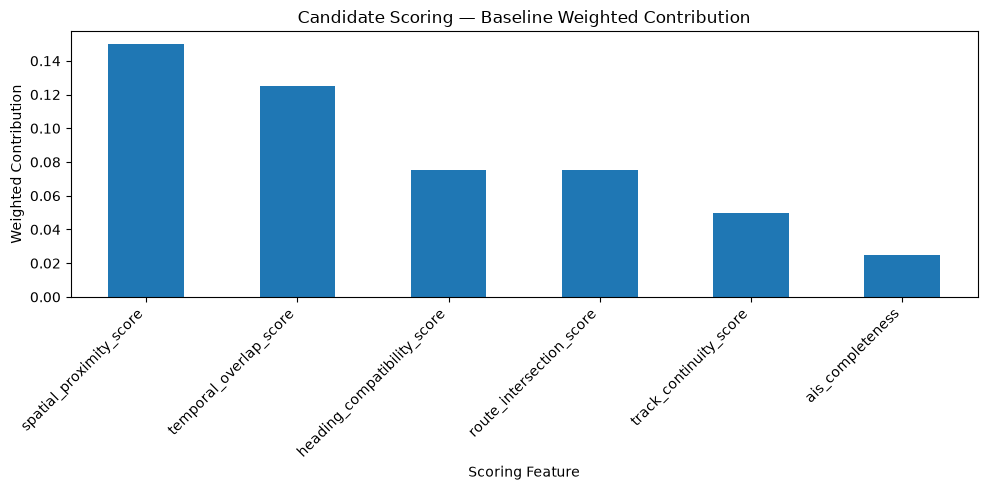

In [11]:
import matplotlib.pyplot as plt

breakdown = pd.DataFrame({
    "Feature": list(baseline.contributions.keys()),
    "Weighted Contribution": list(baseline.contributions.values()),
})

ax = breakdown.plot(
    x="Feature",
    y="Weighted Contribution",
    kind="bar",
    legend=False,
    figsize=(10, 5),
)

ax.set_title("Candidate Scoring — Baseline Weighted Contribution")
ax.set_xlabel("Scoring Feature")
ax.set_ylabel("Weighted Contribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Score-breakdown visualization status

This visualization shows the weighted contribution of each scoring feature
for an implementation-level baseline sensitivity case.

It is **not** a visualization of a real ranked vessel candidate.

No persisted candidate-ranking rows were available for this validation run,
therefore no real MMSI, candidate rank, or real-world candidate score is
visualized here.

In [12]:
evidence = build_candidate_evidence(
    mmsi="IMPLEMENTATION_TEST",
    score=baseline,
)

print(evidence["summary"])
print()
print("MMSI:", evidence["mmsi"])
print("Total score:", evidence["total_score"])
print("Feature scores:", evidence["feature_scores"])
print("Weighted contributions:", evidence["weighted_contributions"])
print("Uncertainty:", evidence["uncertainty_score"])
print("Limitations:", evidence["limitations"])

Highest-ranked candidate under available evidence. This is an investigative lead, not a confirmed polluter.

MMSI: IMPLEMENTATION_TEST
Total score: 0.5
Feature scores: {'spatial_proximity_score': 0.5, 'temporal_overlap_score': 0.5, 'heading_compatibility_score': 0.5, 'route_intersection_score': 0.5, 'track_continuity_score': 0.5, 'ais_completeness': 0.5}
Weighted contributions: {'spatial_proximity_score': 0.15, 'temporal_overlap_score': 0.125, 'heading_compatibility_score': 0.075, 'route_intersection_score': 0.075, 'track_continuity_score': 0.05, 'ais_completeness': 0.025}
Uncertainty: None
Limitations: ['Candidate ranking is decision support only.', 'A candidate ranking does not establish legal responsibility.', 'Evidence quality depends on SAR, drift, AIS coverage, and compatibility validation.']


In [13]:
assert evidence["total_score"] == baseline.total_score
assert evidence["feature_scores"]["spatial_proximity_score"] == baseline.spatial_proximity_score
assert evidence["feature_scores"]["temporal_overlap_score"] == baseline.temporal_overlap_score
assert evidence["feature_scores"]["heading_compatibility_score"] == baseline.heading_compatibility_score
assert evidence["feature_scores"]["route_intersection_score"] == baseline.route_intersection_score
assert evidence["feature_scores"]["track_continuity_score"] == baseline.track_continuity_score
assert evidence["feature_scores"]["ais_completeness"] == baseline.ais_completeness
assert evidence["weighted_contributions"] == baseline.contributions

summary = evidence["summary"].lower()

assert "investigative lead" in summary
assert "not a confirmed polluter" in summary

print("PASS — Evidence fields match the numerical score output.")
print("PASS — Safety language correctly avoids a confirmed-polluter claim.")

PASS — Evidence fields match the numerical score output.
PASS — Safety language correctly avoids a confirmed-polluter claim.


# Day 7 — LEFTOVER / BLOCKED ITEMS

## 1. Real Candidate Score-Breakdown Visualization

**Status:** BLOCKED

A real candidate score-breakdown visualization requires actual persisted
candidate-ranking output containing candidate identifiers and numerical
feature scores.

Current available database state has no persisted candidate rows.
Therefore no real candidate score breakdown is visualized.

No synthetic candidate was created for this deliverable.

---

## 2. Candidate Reduction

**Status:** BLOCKED

Candidate reduction requires an actual end-to-end compatible candidate
retrieval/ranking output with filtering counts.

No validated end-to-end ranked candidate output is currently available.

Therefore candidate reduction is not reported.

---

## 3. Ranking Stability

**Status:** BLOCKED

Ranking stability requires an actual ranked candidate set and repeated
validation/sensitivity runs over that candidate set.

No validated ranked candidate set is currently available.

Therefore ranking stability is not reported.

---

## 4. Recall@1

**Status:** NOT COMPUTED

Verified ground truth identifying the correct polluter/candidate is not
available.

Recall@1 is therefore not calculated.

---

## 5. Recall@3

**Status:** NOT COMPUTED

Verified ground truth identifying the correct polluter/candidate is not
available.

Recall@3 is therefore not calculated.

---

## 6. Real Candidate Evidence Audit

**Status:** BLOCKED

Implementation-level evidence generation was validated against numerical
feature values.

However, a real candidate-level evidence audit requires actual ranked
candidate records with real feature values and evidence output.

No such validated candidate records are currently available.

---

## 7. End-to-End Candidate Ranking

**Status:** BLOCKED / DEPENDENCY

The scoring implementation is available and has passed one-feature
sensitivity validation.

However, a validated end-to-end candidate ranking requires the upstream
candidate retrieval/feature computation pipeline and a compatible scenario
with actual AIS-derived candidate features.

No candidate ranking is fabricated in the absence of this evidence.

# Day 7 — Validation Conclusion

## Completed

- Validated the actual `candidate_scoring.py` implementation.
- Confirmed scoring weights sum to 1.0.
- Performed one-feature-at-a-time sensitivity testing.
- Confirmed score changes match the implemented feature weights.
- Validated implementation-level score contributions.
- Validated that evidence output preserves the numerical feature values and
  weighted contributions.
- Verified that candidate evidence uses investigative language and does not
  claim a confirmed polluter.
- Ran the existing candidate scoring test suite.

## Not Completed Due to Missing Evidence

- Real candidate score-breakdown visualization
- Candidate reduction
- Ranking stability
- Recall@1
- Recall@3
- Real candidate-level evidence audit
- End-to-end validated candidate ranking

These items are documented above under LEFTOVER / BLOCKED.

## Data Integrity Statement

No synthetic MMSIs, candidate records, candidate rankings, ground-truth
labels, or real-world attribution claims were introduced during Day 7
validation.